# GeoSafe — Geospatial Crime Hotspot Detection using DBSCAN

### Objective
Detect geographically dense women-safety incident hotspots from latitude/longitude and characterize each hotspot using crime and safety attributes.

### Methodology
- DBSCAN uses **only latitude and longitude** to detect geographical density.
- Geographic distance is handled with the **Haversine metric**.
- `risk_level`, `safety_score`, and crime information are used only after clustering to describe hotspots.
- DBSCAN is unsupervised, so it does **not** have classification accuracy.
- The notebook reports Silhouette Score, Davies–Bouldin Index, cluster counts, noise percentage, hotspot statistics, and maps.

## Outputs

1. DBSCAN cluster labels for every incident.
2. Candidate-radius comparison.
3. Final clustering metrics.
4. Hotspot summary.
5. Cluster-size analysis.
6. Interactive Folium safety map.
7. Website-ready CSV and HTML outputs.

In [ ]:
# 1. IMPORT LIBRARIES
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium

from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

R_EARTH_KM = 6371.0088
MIN_SAMPLES = 10
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the cleaned dataset

The notebook first tries the Google Drive path used by the project, then a local uploaded-file path.

In [ ]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. LOAD DATA
DRIVE_DATA_PATH = "/content/drive/MyDrive/Women_Safety/Woman_Safety_Dataset_Cleaned.csv"
LOCAL_DATA_PATH = "/mnt/data/Woman_Safety_Dataset_Cleaned.csv"

if os.path.exists(DRIVE_DATA_PATH):
    DATA_PATH = DRIVE_DATA_PATH
elif os.path.exists(LOCAL_DATA_PATH):
    DATA_PATH = LOCAL_DATA_PATH
else:
    raise FileNotFoundError(
        "Dataset not found. Update DATA_PATH to the location of Woman_Safety_Dataset_Cleaned.csv."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset path: {DATA_PATH}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Dataset path: /content/drive/MyDrive/Women_Safety/Woman_Safety_Dataset_Cleaned.csv
Rows: 20,000
Columns: 20


,incident_id,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,safety_score,risk_level,incident_timestamp,incident_year,incident_month,incident_day,incident_hour,incident_dayofweek
0,2b63f176-a5c9-4ac5-adbb-b81c14754ec4,Kolkata,Park Street,22.5875,88.3598,Domestic Violence,23,Afternoon,2.2600,1.0000,768,Stormy,0.8500,Low,2025-05-14 12:40:25,2025,5,14,12,2
1,ef4ba791-e5b5-4146-a3bb-c63e5d695e7c,Kolkata,Garia,22.5656,88.3569,Assault,4,Morning,1.8400,2.0100,626,Clear,0.9200,Low,2024-11-02 08:14:54,2024,11,2,8,5
2,6db79d9c-62d4-4c74-a2f2-295297dbc083,Bhopal,Kolar,23.2425,77.3968,Verbal Abuse,25,Afternoon,5.0400,2.3700,900,Clear,0.8900,Low,2026-01-27 03:45:27,2026,1,27,3,1
3,84fa6f88-339e-44b9-896a-6a548b8466c6,Mumbai,Kurla,18.9976,72.9062,Chain Snatching,19,Afternoon,2.9400,6.1600,114,Clear,0.5800,Medium,2026-02-09 17:34:04,2026,2,9,17,0
4,9e5035a9-0d9b-40fc-a1e8-21702c65096e,Jaipur,Malviya Nagar,26.8996,75.7650,Chain Snatching,56,Evening,6.4300,6.5000,757,Humid,0.4200,High,2025-02-16 06:47:57,2025,2,16,6,6


## 3. Validate the data

DBSCAN itself uses only `latitude` and `longitude`. Other fields are retained for hotspot interpretation.

In [ ]:
# 3. VALIDATE DATA
required_columns = [
    "latitude", "longitude", "crime_count", "safety_score",
    "risk_level", "city", "area", "crime_type"
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for col in ["latitude", "longitude", "crime_count", "safety_score"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df = df.dropna(subset=["latitude", "longitude"]).copy()
df = df[
    df["latitude"].between(-90, 90) &
    df["longitude"].between(-180, 180)
].copy()

print(f"Rows removed for invalid/missing coordinates: {before - len(df):,}")
print(f"Rows available for clustering: {len(df):,}")

Rows removed for invalid/missing coordinates: 0
Rows available for clustering: 20,000


## 4. Visualize the geographical distribution before clustering

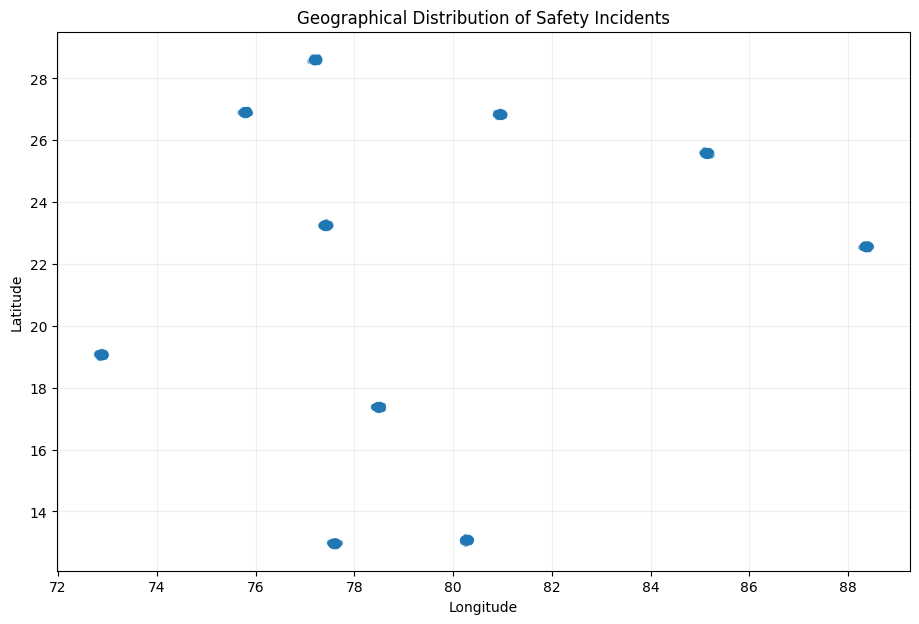

Latitude range : (12.874962, 28.718786)
Longitude range: (72.764977, 88.460186)


In [ ]:
# 4. PRE-CLUSTERING DISTRIBUTION
plt.figure(figsize=(11, 7))
plt.scatter(df["longitude"], df["latitude"], s=8, alpha=0.35)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Safety Incidents")
plt.grid(alpha=0.2)
plt.show()

print("Latitude range :", (df["latitude"].min(), df["latitude"].max()))
print("Longitude range:", (df["longitude"].min(), df["longitude"].max()))

## 5. Prepare coordinates for Haversine DBSCAN

Scikit-learn expects latitude/longitude in radians when using the Haversine metric.

In [ ]:
# 5. HAVERSINE COORDINATES
coords_deg = df[["latitude", "longitude"]].to_numpy(dtype=float)
coords_rad = np.radians(coords_deg)
print("Coordinate matrix:", coords_rad.shape)

Coordinate matrix: (20000, 2)


## 6. k-distance analysis

`min_samples=10` means that a dense neighbourhood needs roughly 10 observations. The curve helps inspect the spatial scale before selecting `eps`.

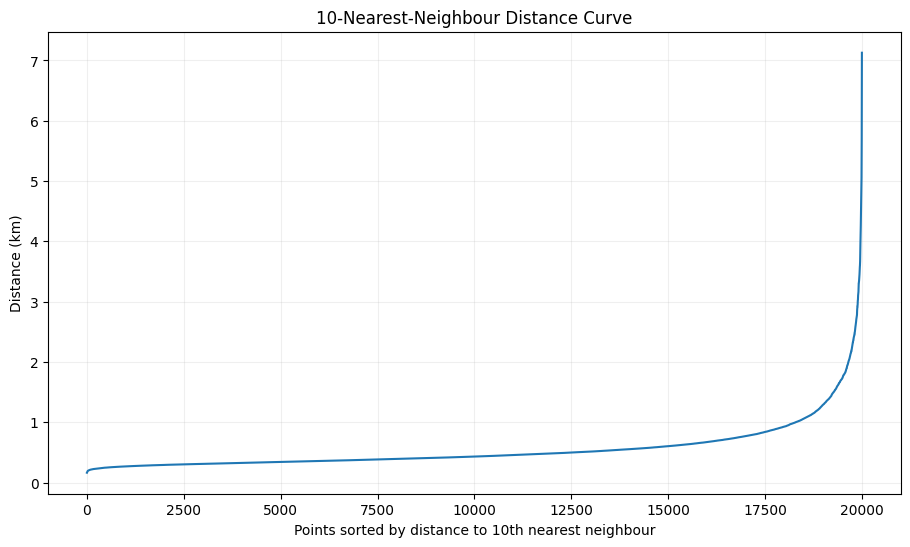

In [ ]:
# 6. K-DISTANCE PLOT
neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES,
    metric="haversine",
    algorithm="ball_tree"
)
neighbors.fit(coords_rad)
distances, _ = neighbors.kneighbors(coords_rad)
k_distances_km = np.sort(distances[:, -1] * R_EARTH_KM)

plt.figure(figsize=(11, 6))
plt.plot(k_distances_km)
plt.xlabel(f"Points sorted by distance to {MIN_SAMPLES}th nearest neighbour")
plt.ylabel("Distance (km)")
plt.title(f"{MIN_SAMPLES}-Nearest-Neighbour Distance Curve")
plt.grid(alpha=0.2)
plt.show()

## 7. Compare candidate geographic radii

We test several radii instead of choosing a value only because it produces a convenient-looking result.

In [ ]:
# 7. PARAMETER COMPARISON
EPS_CANDIDATES_KM = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

def spherical_unit_vectors(coords_rad_subset):
    lat = coords_rad_subset[:, 0]
    lon = coords_rad_subset[:, 1]
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.column_stack([x, y, z])

parameter_results = []

for eps_km in EPS_CANDIDATES_KM:
    test_model = DBSCAN(
        eps=eps_km / R_EARTH_KM,
        min_samples=MIN_SAMPLES,
        metric="haversine",
        algorithm="ball_tree",
        n_jobs=-1
    )
    test_labels = test_model.fit_predict(coords_rad)
    non_noise = test_labels != -1
    n_clusters = len(set(test_labels[non_noise]))

    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        sil = silhouette_score(
            coords_rad[non_noise],
            test_labels[non_noise],
            metric="haversine"
        )
        xyz = spherical_unit_vectors(coords_rad[non_noise])
        dbi = davies_bouldin_score(xyz, test_labels[non_noise])
    else:
        sil, dbi = np.nan, np.nan

    parameter_results.append({
        "eps_km": eps_km,
        "clusters": n_clusters,
        "noise_pct": 100 * np.mean(test_labels == -1),
        "silhouette_score": sil,
        "davies_bouldin_index": dbi
    })

parameter_results = pd.DataFrame(parameter_results)
display(parameter_results)

,eps_km,clusters,noise_pct,silhouette_score,davies_bouldin_index
0,0.2000,24,98.6700,0.8639,0.1789
1,0.2500,133,90.5000,0.6160,0.4805
2,0.3000,247,70.2500,0.3471,0.6370
3,0.3500,175,52.5750,-0.1088,0.7475
4,0.4000,121,40.9500,-0.1947,0.6909
5,0.5000,72,25.0200,-0.1530,0.6512


### Final parameter choice

The project uses **0.30 km (300 m)** as the final starting scale because the goal is to detect *local* crime hotspots rather than entire-city clusters. The parameter table, k-distance curve, and final map should be reviewed together.

If 300 m produces implausibly fragmented or overly broad hotspots, change `FINAL_EPS_KM` and rerun. Do not optimize solely for one metric.

In [ ]:
# 8. FINAL CONFIGURATION
FINAL_EPS_KM = 0.30
print(f"Final eps: {FINAL_EPS_KM:.2f} km")
print(f"min_samples: {MIN_SAMPLES}")

Final eps: 0.30 km
min_samples: 10


## 9. Run final DBSCAN

In [ ]:
# 9. FINAL DBSCAN
dbscan_model = DBSCAN(
    eps=FINAL_EPS_KM / R_EARTH_KM,
    min_samples=MIN_SAMPLES,
    metric="haversine",
    algorithm="ball_tree",
    n_jobs=-1
)

df["cluster"] = dbscan_model.fit_predict(coords_rad)
df["is_noise"] = df["cluster"].eq(-1)

n_clusters = df.loc[~df["is_noise"], "cluster"].nunique()
noise_count = int(df["is_noise"].sum())
noise_pct = 100 * noise_count / len(df)

print(f"Number of clusters: {n_clusters}")
print(f"Noise observations: {noise_count:,}")
print(f"Noise percentage: {noise_pct:.2f}%")

Number of clusters: 247
Noise observations: 14,050
Noise percentage: 70.25%


## 10. Evaluate the final clustering

Silhouette uses Haversine distance directly. Davies–Bouldin is calculated using 3D unit-sphere coordinates rather than raw latitude/longitude degrees.

These are **clustering metrics, not accuracy**.

In [ ]:
# 10. FINAL EVALUATION
cluster_mask = df["cluster"] != -1
unique_clusters = df.loc[cluster_mask, "cluster"].nunique()

if unique_clusters >= 2:
    final_silhouette = silhouette_score(
        coords_rad[cluster_mask.to_numpy()],
        df.loc[cluster_mask, "cluster"],
        metric="haversine"
    )
    coords_3d = spherical_unit_vectors(coords_rad[cluster_mask.to_numpy()])
    final_dbi = davies_bouldin_score(
        coords_3d,
        df.loc[cluster_mask, "cluster"]
    )
else:
    final_silhouette = np.nan
    final_dbi = np.nan

print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Davies–Bouldin Index: {final_dbi:.4f}")
print(f"Clusters: {unique_clusters}")
print(f"Noise percentage: {noise_pct:.2f}%")

Silhouette Score: 0.3471
Davies–Bouldin Index: 0.6370
Clusters: 247
Noise percentage: 70.25%


## 11. Inspect cluster sizes

,incident_count
cluster,
0,219
2,144
5,132
6,126
17,123
11,107
48,105
1,104
39,100


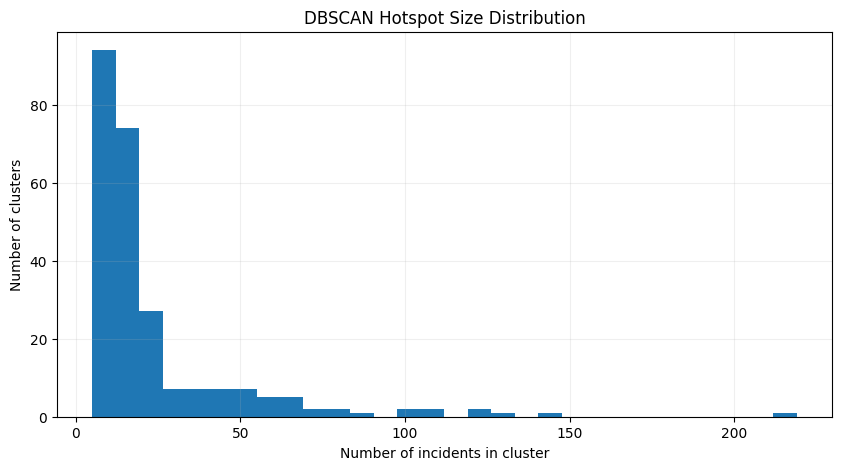

In [ ]:
# 11. CLUSTER SIZE ANALYSIS
clustered_df = df[df["cluster"] != -1].copy()

cluster_sizes = (
    clustered_df.groupby("cluster").size().sort_values(ascending=False)
)

display(cluster_sizes.head(15).rename("incident_count").to_frame())

plt.figure(figsize=(10, 5))
plt.hist(cluster_sizes, bins=30)
plt.xlabel("Number of incidents in cluster")
plt.ylabel("Number of clusters")
plt.title("DBSCAN Hotspot Size Distribution")
plt.grid(alpha=0.2)
plt.show()

## 12. Build the hotspot summary

DBSCAN determines the cluster from coordinates only. These variables are then used to explain what each detected hotspot contains.

In [ ]:
# 12. HOTSPOT SUMMARY
def safe_mode(series):
    mode = series.dropna().mode()
    return mode.iloc[0] if not mode.empty else "Unknown"

hotspot_summary = (
    clustered_df.groupby("cluster").agg(
        incident_count=("cluster", "size"),
        total_crime_count=("crime_count", "sum"),
        average_safety_score=("safety_score", "mean"),
        center_latitude=("latitude", "mean"),
        center_longitude=("longitude", "mean"),
        city=("city", safe_mode),
        area=("area", safe_mode),
        dominant_crime_type=("crime_type", safe_mode)
    ).reset_index()
)

risk_counts = pd.crosstab(clustered_df["cluster"], clustered_df["risk_level"])

for risk in ["Low", "Medium", "High", "Critical"]:
    col = f"{risk.lower()}_risk_incidents"
    if risk in risk_counts.columns:
        hotspot_summary[col] = hotspot_summary["cluster"].map(risk_counts[risk]).fillna(0).astype(int)
    else:
        hotspot_summary[col] = 0

hotspot_summary["high_critical_pct"] = (
    (hotspot_summary["high_risk_incidents"] + hotspot_summary["critical_risk_incidents"])
    / hotspot_summary["incident_count"] * 100
)

hotspot_summary["crime_per_incident"] = (
    hotspot_summary["total_crime_count"] / hotspot_summary["incident_count"]
)

hotspot_summary = hotspot_summary.sort_values(
    ["total_crime_count", "incident_count"],
    ascending=False
).reset_index(drop=True)

hotspot_summary["hotspot_rank"] = np.arange(1, len(hotspot_summary) + 1)

display(hotspot_summary.head(20))

,cluster,incident_count,total_crime_count,average_safety_score,center_latitude,center_longitude,city,area,dominant_crime_type,low_risk_incidents,medium_risk_incidents,high_risk_incidents,critical_risk_incidents,high_critical_pct,crime_per_incident,hotspot_rank
0,0,219,7037,0.7226,25.5903,85.1366,Patna,Patliputra,Harassment,105,74,34,6,18.2648,32.1324,1
1,2,144,4482,0.7031,13.0886,80.2760,Chennai,Adyar,Verbal Abuse,66,43,31,4,24.3056,31.1250,2
2,5,132,4411,0.7133,12.9737,77.5774,Bengaluru,Koramangala,Chain Snatching,69,32,27,4,23.4848,33.4167,3
3,17,123,4246,0.6994,23.2619,77.4183,Bhopal,TT Nagar,Verbal Abuse,52,46,20,5,20.3252,34.5203,4
4,6,126,3704,0.7367,28.6154,77.2005,Delhi,Saket,Assault,60,48,16,2,14.2857,29.3968,5
5,1,104,3386,0.6953,22.5573,88.3522,Kolkata,Park Street,Cyber Crime,46,34,20,4,23.0769,32.5577,6
6,48,105,3344,0.7358,26.8541,80.9457,Lucknow,Gomti Nagar,Cyber Crime,52,37,15,1,15.2381,31.8476,7
7,39,100,3204,0.7022,25.6119,85.1424,Patna,Rajendra Nagar,Night Safety Complaint,45,35,19,1,20.0000,32.0400,8
8,11,107,3121,0.6904,26.8384,80.9533,Lucknow,Aliganj,Night Safety Complaint,49,30,26,2,26.1682,29.1682,9
9,106,89,2905,0.7228,13.0823,80.2527,Chennai,Velachery,Kidnapping,41,34,13,1,15.7303,32.6404,10


## 13. Website-ready hotspot table

In [ ]:
# 13. WEBSITE HOTSPOTS
website_hotspots = hotspot_summary[
    [
        "hotspot_rank", "cluster", "city", "area",
        "center_latitude", "center_longitude",
        "incident_count", "total_crime_count",
        "average_safety_score", "high_critical_pct",
        "dominant_crime_type"
    ]
].copy()

display(website_hotspots.head(20))
print(f"Website hotspot records: {len(website_hotspots):,}")

,hotspot_rank,cluster,city,area,center_latitude,center_longitude,incident_count,total_crime_count,average_safety_score,high_critical_pct,dominant_crime_type
0,1,0,Patna,Patliputra,25.5903,85.1366,219,7037,0.7226,18.2648,Harassment
1,2,2,Chennai,Adyar,13.0886,80.2760,144,4482,0.7031,24.3056,Verbal Abuse
2,3,5,Bengaluru,Koramangala,12.9737,77.5774,132,4411,0.7133,23.4848,Chain Snatching
3,4,17,Bhopal,TT Nagar,23.2619,77.4183,123,4246,0.6994,20.3252,Verbal Abuse
4,5,6,Delhi,Saket,28.6154,77.2005,126,3704,0.7367,14.2857,Assault
5,6,1,Kolkata,Park Street,22.5573,88.3522,104,3386,0.6953,23.0769,Cyber Crime
6,7,48,Lucknow,Gomti Nagar,26.8541,80.9457,105,3344,0.7358,15.2381,Cyber Crime
7,8,39,Patna,Rajendra Nagar,25.6119,85.1424,100,3204,0.7022,20.0000,Night Safety Complaint
8,9,11,Lucknow,Aliganj,26.8384,80.9533,107,3121,0.6904,26.1682,Night Safety Complaint
9,10,106,Chennai,Velachery,13.0823,80.2527,89,2905,0.7228,15.7303,Kidnapping


Website hotspot records: 247


## 14. Visualize DBSCAN clusters

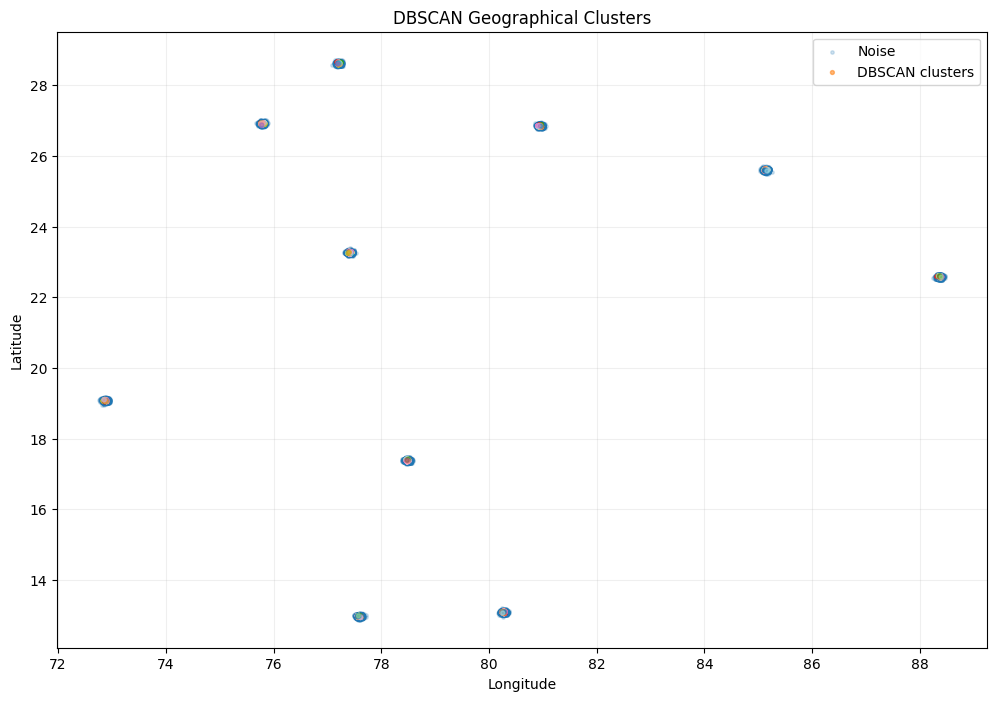

In [ ]:
# 14. CLUSTER MAP
plt.figure(figsize=(12, 8))

noise = df[df["cluster"] == -1]
non_noise = df[df["cluster"] != -1]

plt.scatter(
    noise["longitude"], noise["latitude"],
    s=6, alpha=0.20, label="Noise"
)

plt.scatter(
    non_noise["longitude"], non_noise["latitude"],
    c=non_noise["cluster"], cmap="tab20",
    s=8, alpha=0.55, label="DBSCAN clusters"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Geographical Clusters")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 15. Interactive geographical safety map

The map contains:
- a weighted crime-intensity heatmap;
- DBSCAN hotspot markers;
- a popup for each hotspot with safety and crime statistics.

In [ ]:
# ============================================================
# 15. INTERACTIVE FOLIUM MAP
# ============================================================

center = [
    df["latitude"].mean(),
    df["longitude"].mean()
]

m = folium.Map(
    location=center,
    zoom_start=5,
    tiles=None
)

# Esri World Street Map
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri",
    name="Esri World Street Map",
    overlay=False,
    control=True
).add_to(m)

heat_data = df[["latitude", "longitude", "crime_count"]].dropna().copy()
heat_data["crime_count"] = heat_data["crime_count"].clip(lower=0)

HeatMap(
    heat_data[["latitude", "longitude", "crime_count"]].values.tolist(),
    radius=15,
    blur=20,
    min_opacity=0.25,
    max_zoom=12
).add_to(m)

hotspot_layer = folium.FeatureGroup(name="DBSCAN Hotspots", show=True)

for _, row in website_hotspots.iterrows():
    popup_html = f'''
    <div style="width:260px">
        <h4>Hotspot #{int(row["hotspot_rank"])}</h4>
        <b>City:</b> {row["city"]}<br>
        <b>Area:</b> {row["area"]}<br>
        <b>Incidents:</b> {int(row["incident_count"]):,}<br>
        <b>Total crime count:</b> {int(row["total_crime_count"]):,}<br>
        <b>Average safety score:</b> {row["average_safety_score"]:.2f}<br>
        <b>High/Critical:</b> {row["high_critical_pct"]:.2f}%<br>
        <b>Dominant crime:</b> {row["dominant_crime_type"]}<br>
    </div>
    '''

    folium.CircleMarker(
        location=[row["center_latitude"], row["center_longitude"]],
        radius=7,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f'Hotspot #{int(row["hotspot_rank"])} — {row["city"]}',
        fill=True,
        fill_opacity=0.85,
        weight=1
    ).add_to(hotspot_layer)

hotspot_layer.add_to(m)
folium.LayerControl().add_to(m)

m

## 16. Export outputs for the website

Files:
- `geosafe_clustered_incidents.csv`
- `geosafe_hotspots.csv`
- `geosafe_dbscan_metrics.csv`
- `geosafe_dbscan_parameter_comparison.csv`
- `geosafe_hotspot_map.html`

In [ ]:
# 16. EXPORT OUTPUTS
if os.path.exists("/content/drive/MyDrive/Women_Safety"):
    OUTPUT_DIR = "/content/drive/MyDrive/Women_Safety/outputs"
else:
    OUTPUT_DIR = "/mnt/data/geosafe_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

clustered_output = os.path.join(OUTPUT_DIR, "geosafe_clustered_incidents.csv")
hotspots_output = os.path.join(OUTPUT_DIR, "geosafe_hotspots.csv")
metrics_output = os.path.join(OUTPUT_DIR, "geosafe_dbscan_metrics.csv")
parameters_output = os.path.join(OUTPUT_DIR, "geosafe_dbscan_parameter_comparison.csv")
map_output = os.path.join(OUTPUT_DIR, "geosafe_hotspot_map.html")

df.to_csv(clustered_output, index=False)
website_hotspots.to_csv(hotspots_output, index=False)

final_metrics = pd.DataFrame([{
    "eps_km": FINAL_EPS_KM,
    "min_samples": MIN_SAMPLES,
    "distance_metric": "haversine",
    "number_of_clusters": unique_clusters,
    "noise_count": noise_count,
    "noise_percentage": noise_pct,
    "silhouette_score": final_silhouette,
    "davies_bouldin_index": final_dbi
}])

final_metrics.to_csv(metrics_output, index=False)
parameter_results.to_csv(parameters_output, index=False)
m.save(map_output)

print("Outputs saved:")
for path in [clustered_output, hotspots_output, metrics_output, parameters_output, map_output]:
    print(" -", path)

Outputs saved:
 - /content/drive/MyDrive/Women_Safety/outputs/geosafe_clustered_incidents.csv
 - /content/drive/MyDrive/Women_Safety/outputs/geosafe_hotspots.csv
 - /content/drive/MyDrive/Women_Safety/outputs/geosafe_dbscan_metrics.csv
 - /content/drive/MyDrive/Women_Safety/outputs/geosafe_dbscan_parameter_comparison.csv
 - /content/drive/MyDrive/Women_Safety/outputs/geosafe_hotspot_map.html


## 17. Final verification

Before integrating the results into the website, confirm:
- DBSCAN used only latitude/longitude.
- Haversine distance was used.
- `eps` is expressed in kilometres.
- Noise (`-1`) is not treated as a hotspot.
- DBSCAN metrics are not called accuracy.
- The map shows geographically meaningful clusters.
- The hotspot table contains the safety/crime context needed by the website.

In [ ]:
# 17. FINAL VERIFICATION
print("FINAL DBSCAN SUMMARY")
print("=" * 50)
print(f"Dataset records      : {len(df):,}")
print(f"eps                  : {FINAL_EPS_KM:.2f} km")
print(f"min_samples          : {MIN_SAMPLES}")
print(f"Clusters             : {unique_clusters}")
print(f"Noise records        : {noise_count:,}")
print(f"Noise percentage     : {noise_pct:.2f}%")
print(f"Silhouette Score     : {final_silhouette:.4f}")
print(f"Davies-Bouldin Index : {final_dbi:.4f}")
print(f"Website hotspots     : {len(website_hotspots):,}")
print("=" * 50)

assert "cluster" in df.columns
assert len(website_hotspots) == unique_clusters
assert os.path.exists(map_output)

print("Notebook verification completed successfully.")

FINAL DBSCAN SUMMARY
Dataset records      : 20,000
eps                  : 0.30 km
min_samples          : 10
Clusters             : 247
Noise records        : 14,050
Noise percentage     : 70.25%
Silhouette Score     : 0.3471
Davies-Bouldin Index : 0.6370
Website hotspots     : 247
Notebook verification completed successfully.


# Final project interpretation

### Risk classification
Decision Tree, Random Forest, Naive Bayes, and KNN classify/predict safety risk and should be reported with Accuracy, Precision, Recall, F1-score, and confusion matrices.

### Geospatial hotspot detection
DBSCAN identifies geographically dense incident clusters and should be reported with cluster count, noise percentage, Silhouette Score, Davies–Bouldin Index, hotspot statistics, and an interactive geographical map.

The two components complement each other:
**classification describes risk; clustering describes where incidents are concentrated.**